# Fitness Trainer
Authors: Georg and Martina

##### Plan

Change file names (jumping_jacks → jumpingjacks, incorrect name in some cases, etc.), just in case / done in `rename_files.py`

---

**Data loading**

Go through all `.csv` files in the data folder and convert them into dataframes. Add column with activity label (int). Treat phone placement and frequency combinations differently:
- **frequency**: we can then choose only one for the final model
- **placement**: two models in the end - ask user to choose placement before starting

---

*First data processing:* gyro unit and timestamp standardization, NaN handling

---

**Feature extraction**

We will use windows to analyze the data. This way in the final application we can make predictions in real time ("continuously").

For each window:
1. Apply StandardScaler to the raw sensor data of the window *(second data processing)*
2. Extract features from the scaled window:
   - max amplitude
   - median amplitude
   - standard deviation
   - dominant frequency (using FFT)
   - acceleration magnitude (using 3 axes)
   - correlation between axes (orientation)

Create new dataframes with the extracted features and the activity labels / maintain different frequency and placement groups.

The columns should be something like: `['activity_label', 'acc_x_median', 'acc_x_std', 'acc_x_dominant_freq', 'acc_y_median', 'acc_y_std', ...]`

---

**Model selection**

- Plot features per activity label to identify patterns
- Choose the most relevant features OR use all (eval. according to results)
- Try different kernels, parameters, train-test split ratios, etc.
- Evaluate using appropriate metrics
- Choose best model(s)*

---

**Application**

Real-time activity recognition using the best model(s)* & pyglet.

> *Two models: one for `hand`, one for `pocket`


## Imports

In [74]:

import pandas as pd
import numpy as np
import os

# machine learning: preprocessing, models, evaluation
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to export the model(s)
import joblib

import warnings
warnings.filterwarnings('ignore')

## Data pre-processing

Raw sensor data from CSV files is loaded and organized into four groups based on sampling rate and device placement. Before feature extraction, three pre-processing steps are applied:

1. **Gyroscope unit normalization**: as pointed out in the Discord group chat, some devices record gyroscope data in degrees/s, others in rad/s. All data is converted to rad/s for consistency.
2. **NaN removal**: any rows with missing sensor values are dropped.
3. **Timestamp normalization**: timestamps are shifted to start at 0 for each recording, making them comparable across sessions.

### Loading raw data

In [75]:
data_folder = 'data'

# walk through the data folder and collect all CSV file paths
all_csv_paths = []
for dirpath, dirnames, filenames in os.walk(data_folder):
    for filename in filenames:
        if filename.endswith('.csv'):
            all_csv_paths.append((os.path.join(dirpath, filename), filename))

# map activity names in filenames to integer labels
# (required by sklearn classifiers)
ACTIVITY_LABELS = {
    'running': 0,
    'rowing': 1,
    'jumpingjacks': 2,
    'lifting': 3
}

# helper function to read CSV files into DataFrames and assign activity labels based on filename
def make_df_list(csv_paths, keyword):
    dfs = []
    for full_path, filename in csv_paths:
        if keyword in filename:
            df = pd.read_csv(full_path)
            for activity, label in ACTIVITY_LABELS.items():
                if activity in filename:
                    df['activity_label'] = label
                    break
            dfs.append(df)
    return dfs

# create separate lists of DataFrames for each freq × placement combination
dfs_20Hz_hand   = make_df_list(all_csv_paths, '20Hz-hand')
dfs_20Hz_pocket = make_df_list(all_csv_paths, '20Hz-pocket')
dfs_100Hz_hand  = make_df_list(all_csv_paths, '100Hz-hand')
dfs_100Hz_pocket = make_df_list(all_csv_paths, '100Hz-pocket')

# store all lists in a dictionary for easy access later
all_df_lists = {
    '20Hz_hand':    dfs_20Hz_hand,
    '20Hz_pocket':  dfs_20Hz_pocket,
    '100Hz_hand':   dfs_100Hz_hand,
    '100Hz_pocket': dfs_100Hz_pocket
}

In [76]:
# check the number of dataframes in each list to verify that they were read correctly
print("Number of dataframes in dfs_20Hz_hand:", len(dfs_20Hz_hand))
print("Number of dataframes in dfs_20Hz_pocket:", len(dfs_20Hz_pocket))
print("Number of dataframes in dfs_100Hz_hand:", len(dfs_100Hz_hand))
print("Number of dataframes in dfs_100Hz_pocket:", len(dfs_100Hz_pocket))

Number of dataframes in dfs_20Hz_hand: 212
Number of dataframes in dfs_20Hz_pocket: 190
Number of dataframes in dfs_100Hz_hand: 191
Number of dataframes in dfs_100Hz_pocket: 190


Total CSV files found: 843

       Group  Freq Placement  Recordings  Total samples  running  rowing  jumpingjacks  lifting
   20Hz_hand  20Hz      hand         212          40413       72      45            50       45
 20Hz_pocket  20Hz    pocket         190          36891       50      45            50       45
  100Hz_hand 100Hz      hand         191         175040       50      45            51       45
100Hz_pocket 100Hz    pocket         190         173871       50      45            50       45


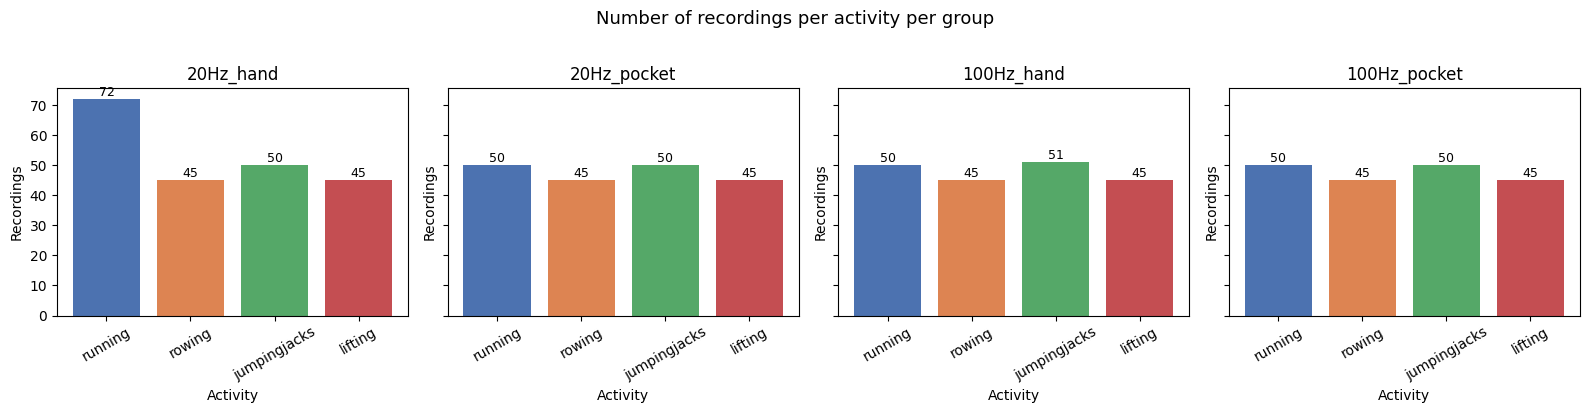

In [77]:
label_names = {v: k for k, v in ACTIVITY_LABELS.items()}

print(f"Total CSV files found: {len(all_csv_paths)}\n")

rows = []
for group, dfs in all_df_lists.items():
    freq, placement = group.split('_')
    counts = {name: 0 for name in ACTIVITY_LABELS}
    total_samples = 0
    for df in dfs:
        label = int(df['activity_label'].iloc[0])
        counts[label_names[label]] += 1
        total_samples += len(df)
    rows.append({
        'Group': group,
        'Freq': freq,
        'Placement': placement,
        'Recordings': len(dfs),
        'Total samples': total_samples,
        **{name: counts[name] for name in ACTIVITY_LABELS}
    })

overview = pd.DataFrame(rows)
print(overview.to_string(index=False))

# bar chart: number of recordings per activity per group
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (_, row) in zip(axes, overview.iterrows()):
    activity_counts = [row[name] for name in ACTIVITY_LABELS]
    bars = ax.bar(list(ACTIVITY_LABELS.keys()), activity_counts,
                  color=['#4C72B0','#DD8452','#55A868','#C44E52'])
    ax.set_title(row['Group'])
    ax.set_xlabel('Activity')
    ax.set_ylabel('Recordings')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, activity_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(val), ha='center', va='bottom', fontsize=9)

plt.suptitle('Number of recordings per activity per group', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Dataset observations:**

The dataset was collected by 10 participants. Each participant recorded 5 repetitions per activity, 
per sampling rate, and per placement, yielding an expected baseline of:
4 activities × 2 frequencies × 2 placements × 5 repetitions × 10 participants = **800 recordings total**.

The distribution is largely balanced across groups and activities (~45–51 recordings each), 
with one exception: `running` in the `20Hz_hand` group contains 72 recordings instead of the 
expected ~50. This is because one participant (Daniel) recorded additional sessions for that 
activity/configuration combination.

### Gyroscope unit normalization

We noticed that some DIPPID devices report gyroscope values in degrees/s while others use rad/s. Since the magnitude of the signal differs drastically between units (degrees/s values typically exceed 100), we detect the unit automatically and convert to rad/s where needed.

In [78]:
# function to check if gyro data is in radians or degrees
def radian_or_degree(df):
    for col in df.columns:
        if 'gyro' in col:
            if df[col].abs().max() > 100:
                return 'degree'
    return 'radian'

# function to convert gyro data from degrees to radians
def degree_to_radian(df):
    for col in df.columns:
        if 'gyro' in col:
            df[col] = np.deg2rad(df[col])
    return df

# Note: we use df[col] = ... to modify in place rather than returning a copy,
# since the DataFrames are already stored in all_df_lists.

In [79]:
# convert all gyro data to radians if needed
for dfs in all_df_lists.values():
    for df in dfs:
        if radian_or_degree(df) == 'degree':
            degree_to_radian(df)

### Removing NaN values


Rows containing NaN in any sensor column are dropped.

In [80]:
# drop any rows with NaN values (if any)
for key, dfs in all_df_lists.items():
    all_df_lists[key] = [df.dropna() for df in dfs]

### Modify timestamps to start at 0s

To make recordings comparable and simplify windowing, we subtract the minimum timestamp from each recording so that all sessions start at t=0. 

In [81]:
# create separate lists to hold the timestamp-normalized dataframes
ts_normalized_20Hz_hand = []
ts_normalized_20Hz_pocket = []
ts_normalized_100Hz_hand = []
ts_normalized_100Hz_pocket = []

# create a dictionary to hold the timestamp-normalized dataframes for easy access
all_timestamp_normalized_dfs = {
    '20Hz_hand': ts_normalized_20Hz_hand,
    '20Hz_pocket': ts_normalized_20Hz_pocket,
    '100Hz_hand': ts_normalized_100Hz_hand,
    '100Hz_pocket': ts_normalized_100Hz_pocket
}

# from each row in the timestamp column in each dataframe, the minimum timestamp is subtracted 
for key, dfs in all_df_lists.items():
    for df in dfs:
        min_timestamp = df['timestamp'].min()
        df_tmp = df.copy()
        df_tmp['timestamp'] = (df_tmp['timestamp'] - min_timestamp)
        all_timestamp_normalized_dfs[key].append(df_tmp)

In [82]:
# verify timestamp normalization: first recording of 20Hz_hand should start at 0
sample_df = all_timestamp_normalized_dfs['20Hz_hand'][0]
print("First 3 rows after timestamp normalization:")
print(sample_df.head(3).to_string(index=False))
print(f"\nTimestamp range: {sample_df['timestamp'].min():.4f}s → {sample_df['timestamp'].max():.4f}s")
print(f"Duration: {sample_df['timestamp'].max():.2f}s | Samples: {len(sample_df)}")

First 3 rows after timestamp normalization:
 id  timestamp     acc_x     acc_y     acc_z    gyro_x    gyro_y   gyro_z  activity_label
  1   0.000000 -6.207352  1.385513 -1.728902 -0.395213  0.096939 2.800580               2
  2   0.062567 -3.385806 -0.283595  1.610046 -3.393400 -4.149738 4.316984               2
  3   0.128285 -2.509397 -1.178308  1.921707  0.048470 -4.837366 5.885586               2

Timestamp range: 0.0000s → 9.9302s
Duration: 9.93s | Samples: 160


## Feature extraction

Raw sensor signals are not fed directly to the classifier. Instead, we extract a compact set of descriptive features from fixed-length windows of the signal. This approach has two advantages:

1. It reduces dimensionality while retaining the most informative signal characteristics.
2. It enables real-time prediction: the classifier operates on one window at a time, allowing continuous activity recognition without reprocessing the full recording history.

### Windowing

We segment the raw signal into overlapping windows of fixed duration. Each window becomes 
one independent sample for the classifier.

We started with **2-second windows**, which we considered long enough to capture at least 
one full movement cycle for all four activities.

We chose **50% overlap** to get more training samples without too much redundancy. 

We also define the **80/20 train-test split** here since it directly affects how windows 
are distributed. It is important to point out that the split is done at the **recording level**, not the window 
level (we separate files, not windows). This avoids data leakage: if we split by window, windows from the same recording 
would appear in both train and test sets, which would artificially inflate accuracy since 
consecutive windows are highly correlated. Note: We figured that out by doing it wrongly the first time.

We'll revisit all three of these choices later once we have a working model to 
evaluate them against.

In [83]:
window_size_seconds = 2  # duration of each window in seconds

# number of samples per window at each sampling rate
WINDOW_SIZE_20HZ  = window_size_seconds * 20   # = 40 samples
WINDOW_SIZE_100HZ = window_size_seconds * 100  # = 200 samples

OVERLAP = 0.5  # 50% overlap between consecutive windows

In [84]:
# function to create overlapping windows from a dataframe
def get_windows(df, window_size):
    step = int(window_size * (1 - OVERLAP))
    windows = []
    for start in range(0, len(df) - window_size + 1, step):
        window = df.iloc[start:start + window_size]
        windows.append(window)
    return windows

### Feature set

For each window, we extract features from 8 signal channels:
`acc_x`, `acc_y`, `acc_z`, `gyro_x`, `gyro_y`, `gyro_z`, `acc_magnitude`, `gyro_magnitude`

The magnitude channels are derived as the Euclidean norm of the three axes and capture overall movement intensity *independent of device orientation*.

**Per-channel features (4 × 8 = 32 features):**

- **`max`**: Peak signal amplitude. We thought this feature would be useful for distinguishing high-impact activities 
  (jumping jacks, running) from low-impact ones (lifting, rowing), where 
  accelerations remain moderate throughout.

- **`median`**: Robust central tendency of the signal. At first, we though about using the mean, but since this metric is less sensitive to outliers (which we didn't manage before), we choose it, hoping to get a stable estimate of the "typical" signal level during the window.

- **`std`**: Signal variability. Intuitively, we thought that rhythmic and explosive activities like jumping jacks 
  would produce high variability, while controlled movements like lifting would tend to be more stable.

- **`dominant_freq`**: The frequency of the strongest component in the FFT spectrum 
  (excluding DC component - this we found out after testing, he). Encodes movement cadence; for example, running usually has a higher stride 
  frequency than rowing, making this feature useful for separating activities with 
  different rhythms.

**Cross-axis correlation features (6 features):**

We compute the Pearson correlations between axis pairs:
`acc_x_y`, `acc_x_z`, `acc_y_z`, `gyro_x_y`, `gyro_x_z`, `gyro_y_z`

These were added after initial experiments with only the per-channel features did not yield 
satisfactory results. This was particularly noticeable for distinguishing rowing from lifting, which share similar 
intensity levels but happen in different movement planes. We consulted AI about ways to capture 
3D movement structure, which suggested cross-axis correlations. The idea made sense to us: 
rowing (horizontal) and lifting (vertical) should differ in how their axes move relative to 
each other.

One known limitation is that these features depend on how the device is held. We accepted 
this trade-off assuming most users hold their phone similarly to how we did when collecting 
the dataset.

**Total: 38 features per window.**

In [85]:
cols_to_evaluate = [
    'acc_x', 'acc_y', 'acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'acc_magnitude', 'gyro_magnitude'
]

# function to compute the dominant frequency of a signal using FFT
def get_dominant_frequency(series, sampling_rate):
    n = len(series)
    freqs = np.fft.rfftfreq(n, d=1/sampling_rate)
    fft_magnitude = np.abs(np.fft.rfft(series))
    return freqs[1:][np.argmax(fft_magnitude[1:])]

# function to compute correlation between two signal axes in a window
def get_correlation(window, col1, col2):
    corr = window[col1].corr(window[col2])
    return corr if not np.isnan(corr) else 0.0

# function to extract features from a single window dataframe
def extract_features_from_window(window, sampling_rate):
    window = window.copy()
    # compute magnitude channels before feature extraction
    window['acc_magnitude']  = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
    window['gyro_magnitude'] = np.sqrt(window['gyro_x']**2 + window['gyro_y']**2 + window['gyro_z']**2)

    features = {'activity_label': window['activity_label'].iloc[0]}

    # extract features per channel
    for col in cols_to_evaluate:
        features[f'{col}_max']           = window[col].max()
        features[f'{col}_median']        = window[col].median()
        features[f'{col}_std']           = window[col].std()
        features[f'{col}_dominant_freq'] = get_dominant_frequency(window[col], sampling_rate)

    # cross-axis correlations
    features['acc_x_y_corr']  = get_correlation(window, 'acc_x',  'acc_y')
    features['acc_x_z_corr']  = get_correlation(window, 'acc_x',  'acc_z')
    features['acc_y_z_corr']  = get_correlation(window, 'acc_y',  'acc_z')
    features['gyro_x_y_corr'] = get_correlation(window, 'gyro_x', 'gyro_y')
    features['gyro_x_z_corr'] = get_correlation(window, 'gyro_x', 'gyro_z')
    features['gyro_y_z_corr'] = get_correlation(window, 'gyro_y', 'gyro_z')

    return features

In [86]:
def build_feature_df(dfs, window_size, sampling_rate):
    all_features = []
    for df in dfs:
        windows = get_windows(df, window_size)
        for window in windows:
            feats = extract_features_from_window(window, sampling_rate)
            all_features.append(feats)
    return pd.DataFrame(all_features)

# split by recording, not by window
# before, we split the windows into train/test sets, which we realized was not ideal 
# because windows from the same recording could end up in both sets, leading to data leakag
splits = {}
for key, dfs in all_timestamp_normalized_dfs.items():
    sampling_rate = 20 if '20Hz' in key else 100
    window_size = WINDOW_SIZE_20HZ if '20Hz' in key else WINDOW_SIZE_100HZ

    # 80/20 split with a fixed random seed for reproducibility
    train_dfs, test_dfs = train_test_split(dfs, test_size=0.2, random_state=42)

    train_df = build_feature_df(train_dfs, window_size, sampling_rate)
    test_df  = build_feature_df(test_dfs,  window_size, sampling_rate)

    splits[key] = {'train': train_df, 'test': test_df}
    print(f"{key}: {len(train_df)} train windows, {len(test_df)} test windows")


20Hz_hand: 1425 train windows, 369 test windows
20Hz_pocket: 1315 train windows, 324 test windows
100Hz_hand: 1205 train windows, 295 test windows
100Hz_pocket: 1207 train windows, 286 test windows


In [ ]:
# NOTE HERE WE COULD MAYBE ADD SOME FEATURE VISUALIZATION
# ALSO MAYBE DISCUSS WHY WE DIDN'T DO ANY FEATURE SELECTION, AND USED ALL FEATURES INSTEAD *OR* ACTUALLY DO SOME FEATURE SELECTION AND COMPARE RESULTS

## Trying out different models

### Kernel and OVR/OVO comparison


We first try four SVM kernels (`linear`, `rbf`, `poly`, and `sigmoid`) across all four frequncy-placement groups to see which one works best before tuning anything else.

We also compare if there are any differences when using the "One vs. One" and the "One vs. Rest" multiclass strategies for the SVM.

In [88]:
from sklearn.multiclass import OneVsOneClassifier

# kernels to compare
kernels = ['linear', 'rbf', 'poly', 'sigmoid']

# strategies to compare
strategies = {'OvR': OneVsRestClassifier, 'OvO': OneVsOneClassifier}

kernel_results = {}

# train and evaluate models for each group, kernel, and strategy
for key, split in splits.items():
    X_train = split["train"].drop(columns=["activity_label"])
    y_train = split["train"]["activity_label"]
    X_test  = split["test"].drop(columns=["activity_label"])
    y_test  = split["test"]["activity_label"]

    kernel_results[key] = {s: [] for s in strategies}

    for kernel in kernels:
        for strat_name, strat_cls in strategies.items():
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", strat_cls(SVC(kernel=kernel)))
            ])
            model.fit(X_train, y_train)
            acc = accuracy_score(y_test, model.predict(X_test))
            kernel_results[key][strat_name].append(acc)

    print(f"\n{key}:")
    print(f"  {'kernel':<10} {'OvR':>6} {'OvO':>6}")
    for i, kernel in enumerate(kernels):
        ovr = kernel_results[key]['OvR'][i]
        ovo = kernel_results[key]['OvO'][i]
        print(f"  {kernel:<10} {ovr:>6.3f} {ovo:>6.3f}")



20Hz_hand:
  kernel        OvR    OvO
  linear      0.970  0.984
  rbf         0.981  0.981
  poly        0.970  0.957
  sigmoid     0.802  0.821

20Hz_pocket:
  kernel        OvR    OvO
  linear      0.889  0.951
  rbf         0.898  0.907
  poly        0.880  0.870
  sigmoid     0.654  0.713

100Hz_hand:
  kernel        OvR    OvO
  linear      0.885  0.895
  rbf         0.969  0.983
  poly        0.956  0.969
  sigmoid     0.715  0.732

100Hz_pocket:
  kernel        OvR    OvO
  linear      0.913  0.906
  rbf         0.941  0.937
  poly        0.850  0.857
  sigmoid     0.612  0.713


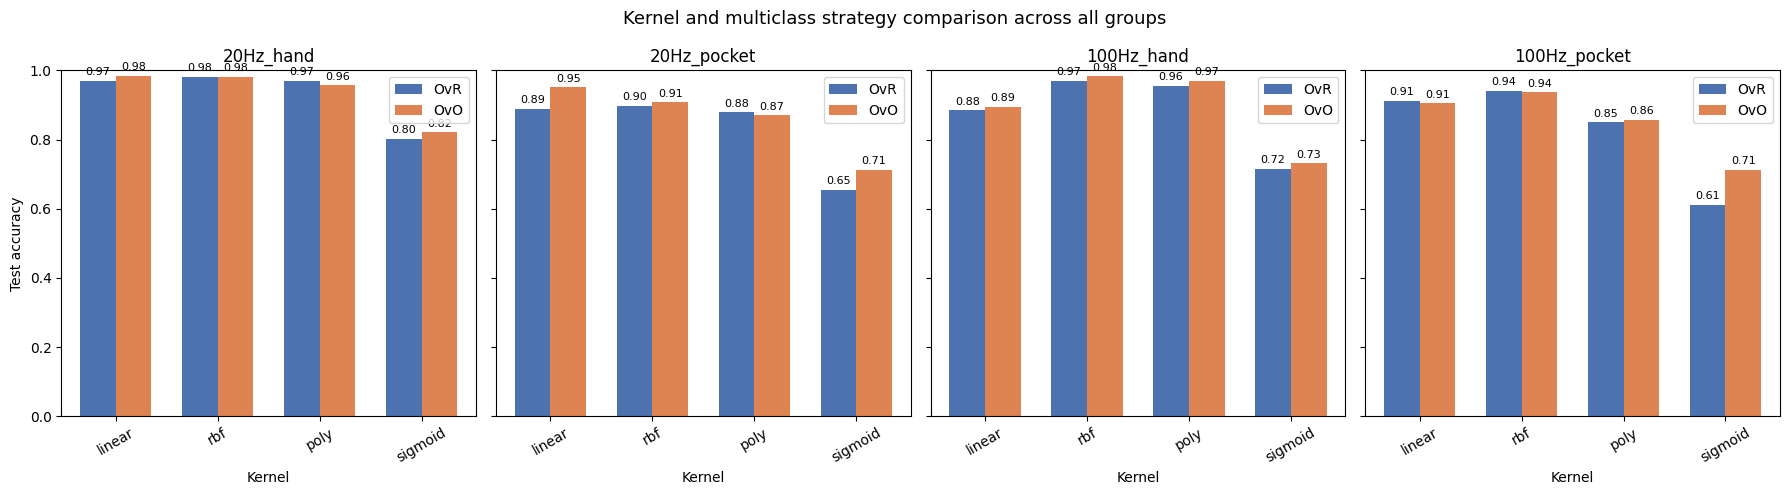

In [89]:
# plot the results in a grouped bar char
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
x = np.arange(len(kernels))
width = 0.35

for ax, (key, results) in zip(axes, kernel_results.items()):
    bars_ovr = ax.bar(x - width/2, results['OvR'], width, label='OvR', color='#4C72B0')
    bars_ovo = ax.bar(x + width/2, results['OvO'], width, label='OvO', color='#DD8452')
    ax.set_title(key)
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(kernels, rotation=30)
    ax.set_xlabel('Kernel')
    ax.legend()
    for bar in list(bars_ovr) + list(bars_ovo):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel('Test accuracy')
plt.suptitle('Kernel and multiclass strategy comparison across all groups', fontsize=13)
plt.tight_layout()
plt.show()

**Results:**

`linear`, `rbf`, and `poly` perform consistently well (0.88–0.98) across all groups, 
while `sigmoid` drops significantly (0.61 - 0.73).

`rbf` is the most consistent overall.

OvO edges out OvR slightly in most cases, but differences are minimal (0 - 0.02). 

We go with **OvO + rbf** as the baseline for remaining comparisons.

### Windowing and split comparison

With OvO + rbf fixed, we now validate our initial assumptions about window size, 
overlap, and train-test split. We run these comparisons on `100Hz_hand` only to get 
a general idea, accepting that results might vary across groups.

In [90]:
# shared setup for windowing comparisons
# uses OvO + rbf to match the chosen baseline from kernel comparison

COMPARISON_DFS = all_timestamp_normalized_dfs['100Hz_hand']
SAMPLING_RATE  = 100

def run_windowing_comparison(dfs, window_size, overlap, test_size):
    step = int(window_size * (1 - overlap))

    def get_windows_custom(df):
        return [df.iloc[s:s+window_size] for s in range(0, len(df)-window_size+1, step)]

    def build_df(dfs_list):
        all_feats = []
        for df in dfs_list:
            for w in get_windows_custom(df):
                all_feats.append(extract_features_from_window(w, SAMPLING_RATE))
        return pd.DataFrame(all_feats)

    train_dfs, test_dfs = train_test_split(dfs, test_size=test_size, random_state=42)
    X_train = build_df(train_dfs); y_train = X_train.pop('activity_label')
    X_test  = build_df(test_dfs);  y_test  = X_test.pop('activity_label')

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', OneVsOneClassifier(SVC(kernel='rbf')))
    ])
    model.fit(X_train, y_train)
    return accuracy_score(y_test, model.predict(X_test))

  Split 60/40: 0.977
  Split 70/30: 0.993
  Split 80/20: 0.983
  Split 90/10: 1.000
  Window 1s: 0.926
  Window 2s: 0.983
  Window 3s: 0.982
  Overlap 50%: 0.983
  Overlap 75%: 0.954


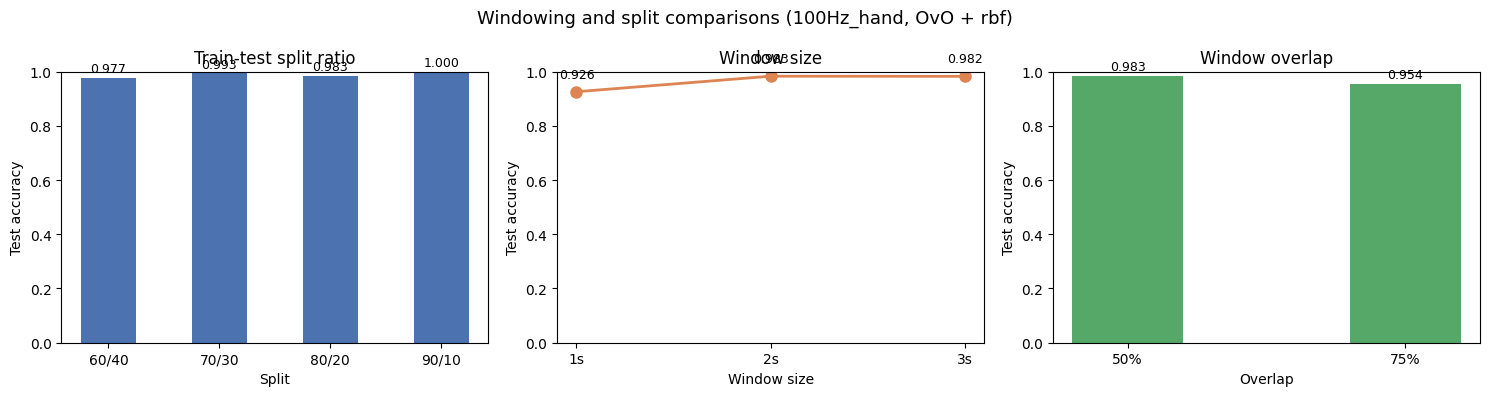

In [ ]:
# NOTE - REVIEW THIS FUNCTION AND IMPROVE PLOTS

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. train-test split
split_ratios = [0.4, 0.3, 0.2, 0.1]
split_labels = ['60/40', '70/30', '80/20', '90/10']
split_accs   = []
for ratio in split_ratios:
    acc = run_windowing_comparison(COMPARISON_DFS, window_size=200, overlap=0.5, test_size=ratio)
    split_accs.append(acc)
    print(f"  Split {split_labels[split_ratios.index(ratio)]}: {acc:.3f}")

axes[0].bar(split_labels, split_accs, color='#4C72B0', width=0.5)
axes[0].set_ylim(0, 1)
axes[0].set_title('Train-test split ratio')
axes[0].set_xlabel('Split'); axes[0].set_ylabel('Test accuracy')
for i, acc in enumerate(split_accs):
    axes[0].text(i, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

# 2. window size
window_sizes_s = [1, 2, 3]
window_accs    = []
for ws in window_sizes_s:
    acc = run_windowing_comparison(COMPARISON_DFS, window_size=ws*100, overlap=0.5, test_size=0.2)
    window_accs.append(acc)
    print(f"  Window {ws}s: {acc:.3f}")

axes[1].plot([f'{w}s' for w in window_sizes_s], window_accs,
             marker='o', color='#DD8452', linewidth=2, markersize=8)
axes[1].set_ylim(0, 1)
axes[1].set_title('Window size')
axes[1].set_xlabel('Window size'); axes[1].set_ylabel('Test accuracy')
for i, acc in enumerate(window_accs):
    axes[1].annotate(f'{acc:.3f}', (i, acc), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

# 3. window overlap
overlaps       = [0.5, 0.75]
overlap_labels = ['50%', '75%']
overlap_accs   = []
for ov in overlaps:
    acc = run_windowing_comparison(COMPARISON_DFS, window_size=200, overlap=ov, test_size=0.2)
    overlap_accs.append(acc)
    print(f"  Overlap {int(ov*100)}%: {acc:.3f}")

axes[2].bar(overlap_labels, overlap_accs, color='#55A868', width=0.4)
axes[2].set_ylim(0, 1)
axes[2].set_title('Window overlap')
axes[2].set_xlabel('Overlap'); axes[2].set_ylabel('Test accuracy')
for i, acc in enumerate(overlap_accs):
    axes[2].text(i, acc + 0.01, f'{acc:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Windowing and split comparisons (100Hz_hand, OvO + rbf)', fontsize=13)
plt.tight_layout()
plt.show()

**Results:**

Differences are small across the board, which suggests the model is fairly robust to these choices.

For the **split**, accuracy goes up with more training data, but 90/10 leaves too few recordings 
for a reliable evaluation, so we stick with **80/20**.

For **window size**, 1s is worse than the other sizes, perhaps because it is too short to capture a full movement cycle 
for slower activities like rowing. 2s and 3s are almost identical, so we keep **2s** since 
shorter windows mean more responsive predictions in the app.

For **overlap**, 50% slightly outperforms 75% here, so we stick with **50%**.

### Scaler comparison



We also test different scaling strategies. StandardScaler (zero mean, unit variance) 
was our default assumption, but MinMaxScaler (scales to [0,1]) is also commonly used. 
We try both individually and combined (MinMax followed by Standard) to see if it makes 
a difference.

In [92]:
# scalers to compare
scalers = {
    'StandardScaler': [('scaler', StandardScaler())],
    'MinMaxScaler':   [('scaler', MinMaxScaler())],
    'MinMax + Standard': [('minmax', MinMaxScaler()), ('standard', StandardScaler())],
}

scaler_results = {}

# train and evaluate models for each scaler
for scaler_name, scaler_steps in scalers.items():
    train_dfs, test_dfs = train_test_split(COMPARISON_DFS, test_size=0.2, random_state=42)

    def build_df(dfs_list):
        all_feats = []
        for df in dfs_list:
            windows = get_windows(df, WINDOW_SIZE_100HZ)
            for w in windows:
                all_feats.append(extract_features_from_window(w, SAMPLING_RATE))
        return pd.DataFrame(all_feats)

    X_train = build_df(train_dfs); y_train = X_train.pop('activity_label')
    X_test  = build_df(test_dfs);  y_test  = X_test.pop('activity_label')

    model = Pipeline(scaler_steps + [('clf', OneVsOneClassifier(SVC(kernel='rbf')))])
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    scaler_results[scaler_name] = acc
    print(f"  {scaler_name:<25} {acc:.3f}")

  StandardScaler            0.983
  MinMaxScaler              0.939
  MinMax + Standard         0.983


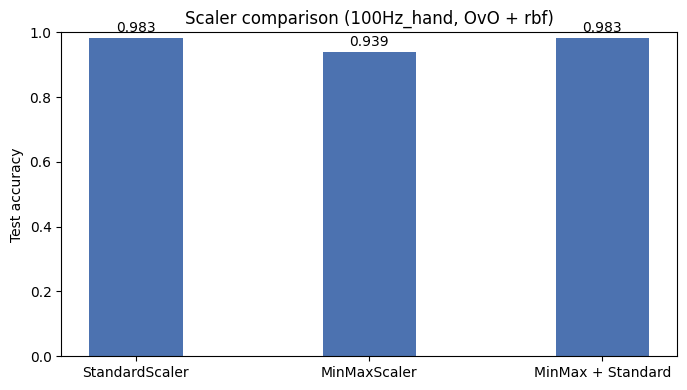

In [93]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(scaler_results.keys(), scaler_results.values(), color='#4C72B0', width=0.4)
ax.set_ylim(0, 1)
ax.set_ylabel('Test accuracy')
ax.set_title('Scaler comparison (100Hz_hand, OvO + rbf)')
for bar, acc in zip(bars, scaler_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

**Results:**

StandardScaler and MinMax + Standard both hit 0.983, while MinMaxScaler alone drops 
to 0.939. This could have to do with features being centered around zero, which MinMaxScaler alone doesn't guarantee. 
We stick with **StandardScaler** since it's simpler and performs just as well.

### Hyperparameter tuning (GridSearch)



With kernel (rbf), strategy (OvO), and scaler (StandardScaler) fixed, we tune the 
remaining SVM hyperparameters `C` and `gamma`.

We search over rbf and poly since those were the strongest kernels, keeping the door 
open in case poly wins for some groups.

In [ ]:
param_grid = {
    "clf__estimator__C":      [0.1, 1, 10, 100],
    "clf__estimator__gamma":  ["scale", "auto", 0.01, 0.001],
    "clf__estimator__kernel": ["rbf", "poly"]
}

grid_results = {}

for key, split in splits.items():
    X_train = split["train"].drop(columns=["activity_label"])
    y_train = split["train"]["activity_label"]
    X_test  = split["test"].drop(columns=["activity_label"])
    y_test  = split["test"]["activity_label"]

    base_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", OneVsOneClassifier(SVC()))
    ])

    grid = GridSearchCV(base_model, param_grid, cv=5, n_jobs=-1)
    grid.fit(X_train, y_train)
    acc = accuracy_score(y_test, grid.predict(X_test))

    grid_results[key] = {'best_params': grid.best_params_, 'accuracy': acc}

    print(f"\n{key}:")
    print(f"  best params: {grid.best_params_}")
    print(f"  accuracy:    {acc:.3f}")


20Hz_hand:
  best params: {'clf__estimator__C': 10, 'clf__estimator__gamma': 'scale', 'clf__estimator__kernel': 'rbf'}
  accuracy:    0.989

20Hz_pocket:
  best params: {'clf__estimator__C': 10, 'clf__estimator__gamma': 0.01, 'clf__estimator__kernel': 'rbf'}
  accuracy:    0.938

100Hz_hand:
  best params: {'clf__estimator__C': 10, 'clf__estimator__gamma': 0.01, 'clf__estimator__kernel': 'rbf'}
  accuracy:    0.936

100Hz_pocket:
  best params: {'clf__estimator__C': 100, 'clf__estimator__gamma': 'scale', 'clf__estimator__kernel': 'rbf'}
  accuracy:    0.944


**Results:**

rbf wins across all four groups, confirming our earlier choice. `C=10` is the most 
common best value, with `100Hz_pocket` needing a higher `C=100` to fit its more 
variable data. `gamma` varies between `scale` and `0.01` depending on the group.

Interestingly, `20Hz_hand` achieves the highest accuracy (0.989), while the 100Hz 
groups land slightly lower (~0.936–0.944). This is a surprise.

These best parameters will be used to train the final models in the next step.

### Confusion matrices

We train one model per group using the best parameters found by GridSearch and plot 
the confusion matrix on the held-out test set. This lets us see not just overall accuracy 
but exactly which activities get confused with each other.

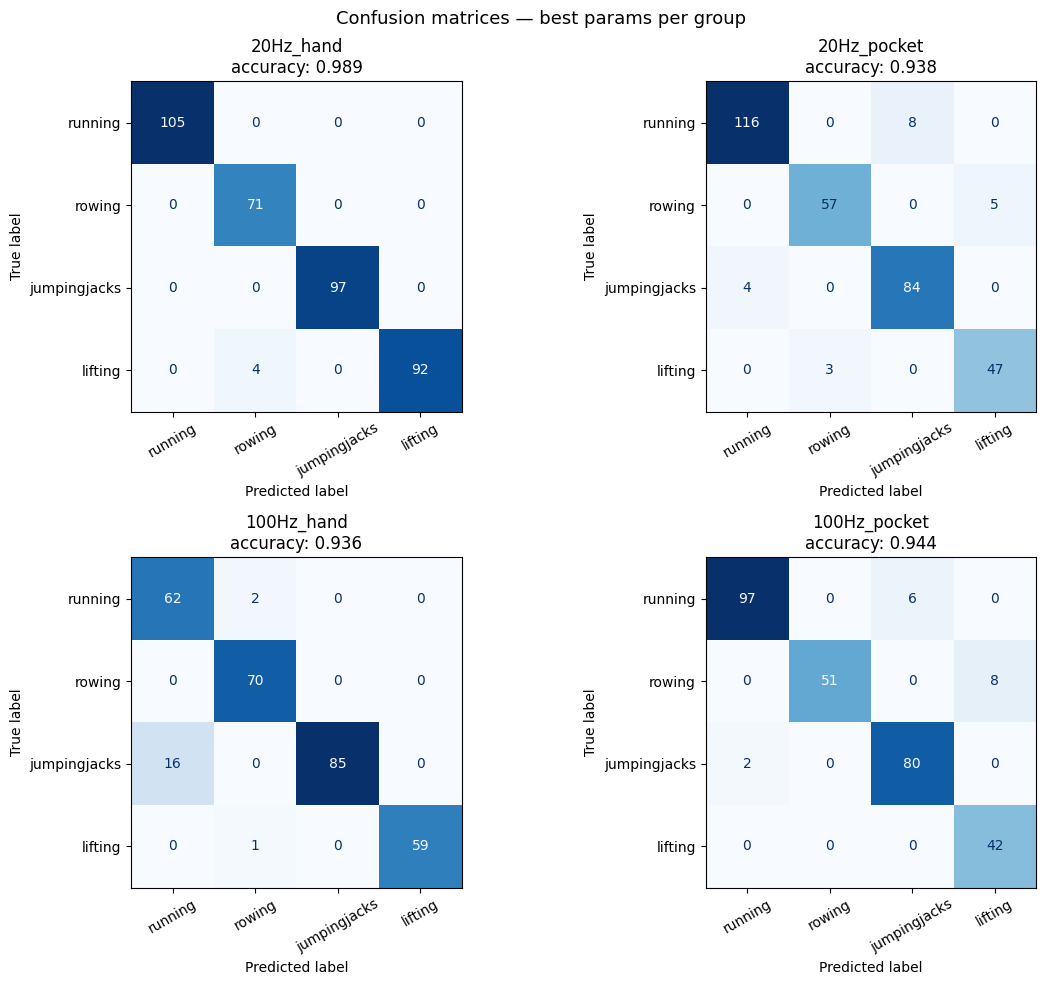

In [ ]:
activity_names = ['running', 'rowing', 'jumpingjacks', 'lifting']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (key, split) in zip(axes, splits.items()):
    X_train = split['train'].drop(columns=['activity_label'])
    y_train = split['train']['activity_label']
    X_test  = split['test'].drop(columns=['activity_label'])
    y_test  = split['test']['activity_label']

    # extract best params for this group
    p = grid_results[key]['best_params']

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", OneVsOneClassifier(SVC(
            C=p['clf__estimator__C'],
            gamma=p['clf__estimator__gamma'],
            kernel=p['clf__estimator__kernel']
        )))
    ])
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=activity_names)
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{key}\naccuracy: {acc:.3f}')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion matrices — best params per group', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# NOTE WE SHOULD ADD RESULTS/ANALYSIS HERE

## Model Export

We retrain one final model per group using the full dataset (train + test combined) 
and the best parameters found by GridSearch. Training on all available data gives the 
model the best possible generalization for real-time use in the app.

The models are saved to disk using `joblib` and will be loaded directly by the fitness trainer 
application at startup.

Note: We will keep only one sampling frequency, but allow the user to choose phone placement before starting, and we will use the corresponding model for classification.

In [97]:
os.makedirs('models_2', exist_ok=True)
models = {}

for key, split in splits.items():
    # combine train and test sets for final training
    full_df = pd.concat([split['train'], split['test']], ignore_index=True)
    X = full_df.drop(columns=['activity_label'])
    y = full_df['activity_label']

    # build model with best params found by GridSearch
    p = grid_results[key]['best_params']
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", OneVsOneClassifier(SVC(
            C=p['clf__estimator__C'],
            gamma=p['clf__estimator__gamma'],
            kernel=p['clf__estimator__kernel'],
            probability=True
        )))
    ])
    model.fit(X, y)
    models[key] = model

    model_filename = f'models_2/{key}_svm_model.joblib'
    joblib.dump(model, model_filename)
    print(f'Exported {model_filename} | C={p["clf__estimator__C"]}, '
          f'gamma={p["clf__estimator__gamma"]}, kernel={p["clf__estimator__kernel"]}')

Exported models_2/20Hz_hand_svm_model.joblib | C=10, gamma=scale, kernel=rbf
Exported models_2/20Hz_pocket_svm_model.joblib | C=10, gamma=0.01, kernel=rbf
Exported models_2/100Hz_hand_svm_model.joblib | C=10, gamma=0.01, kernel=rbf
Exported models_2/100Hz_pocket_svm_model.joblib | C=100, gamma=scale, kernel=rbf
